In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Wed Aug 13 02:38:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
|  0%   56C    P8             39W /  450W |      11MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|██████████| 3/3 [00:00<00:00,  7.17it/s]
Expected types for

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=1.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [21]:
import torch, torch.nn.functional as F
from torch import nn
from pytorch_fid.inception import InceptionV3

class FIDInception(nn.Module):
    """No-crop resize → Inception(pool3). 입력 bf16 OK, 기본 입력범위 -1..1, 기본 clamp=STE."""
    def __init__(self, dims=2048, net_dtype=torch.bfloat16):
        super().__init__()
        self.net = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[dims]]).eval().to(dtype=net_dtype)
        for p in self.net.parameters(): p.requires_grad_(False)

    def forward(self, x, input_range="-1..1", clamp_mode="ste", out_dtype=torch.float32):
        p = next(self.net.parameters()); x = x.to(p.device)
        if input_range == "-1..1": x = (x + 1) * 0.5  # -> [0,1] (이론상)
        # clamp 옵션
        if clamp_mode == "hard":
            x = x.clamp(0, 1)
        elif clamp_mode == "ste":
            xc = x.clamp(0, 1)
            x  = x + (xc - x).detach()  # forward=clamp, backward=identity
        # no-crop resize (왜곡 허용, 전체 보존)
        if x.shape[-2:] != (299, 299):
            x = F.interpolate(x.float(), (299, 299), mode="bilinear", align_corners=False, antialias=True)
        else:
            x = x.float()
        x = x.to(p.dtype)
        feats = self.net(x)[0].squeeze(-1).squeeze(-1)
        return feats.to(out_dtype) if out_dtype is not None else feats

inception = FIDInception()

In [22]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver
from solvers.others.unipc_solver import UniPC_Solver

# 클래스 0–9로 설정
class_ids = [i for i in range(0, 100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
latents = model.get_noise(seeds=class_ids)

NFE = 20
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, raw_output=True)
print(euler_samples.shape)

torch.Size([10, 3, 256, 256])


In [24]:
inception(euler_samples).shape

torch.Size([10, 2048])

0.21887285232543946


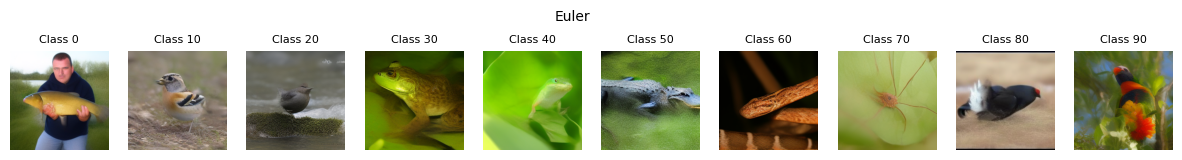

In [33]:
import numpy as np
import torch
import time
from solvers.dual.dynamic.gdual_solver_log import GDual_Solver
from solvers.transforms.loglinear_transform import LogLinearTransform
from solvers.param_extractors.gap_extractor import GAP_Extractor

NFE = 5
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
times = []
for _ in range(100):
    t0 = time.time()
    euler_latents = solver.sample(latents, model_fn)['samples']
    t1 = time.time()
    times.append(t1 - t0)
print(np.mean(times))
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Euler')



0.22152814149856567


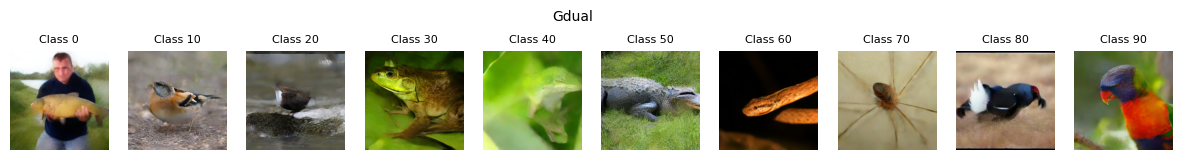

In [ ]:
extractor = GAP_Extractor(input_shape=(4, 32, 32))
transform = LogLinearTransform(gamma_push=True, gamma_max=2, kappa_max=2)
solver = GDual_Solver(noise_schedule, steps=NFE, transform=transform, param_extractor=extractor, exact_first=False, skip_type="time_uniform", time_learning=True).to(model.device)
solver.eval()

pt_file = "logs/CFG4.0/0812-1:logMSE/step_00000700.pt"
state_dict = torch.load(pt_file, map_location='cpu')['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)

times = []
for _ in range(100):
    with torch.no_grad():
        t0 = time.time()
        euler_latents = solver.sample(latents, model_fn)
        t1 = time.time()
        times.append(t1 - t0)
print(np.mean(times))
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Gdual')
